In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Sample - Superstore.csv", encoding="cp1252")

print("Dataset loaded successfully")
print("Rows and Columns:", df.shape)

Dataset loaded successfully
Rows and Columns: (9994, 21)


In [3]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [7]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date columns converted successfully")

Date columns converted successfully


In [9]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [10]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

print("Time features created successfully")

Time features created successfully


In [11]:
df[["Order Date", "Year", "Month", "Month_Name", "Quarter"]].head()

,Order Date,Year,Month,Month_Name,Quarter
0,2016-11-08,2016,11,November,4
1,2016-11-08,2016,11,November,4
2,2016-06-12,2016,6,June,2
3,2015-10-11,2015,10,October,4
4,2015-10-11,2015,10,October,4


In [12]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())
print("Total Orders:", df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity: 37873
Total Orders: 5009
Total Customers: 793


In [13]:
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head(12)

,Year,Month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


In [14]:
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("Date")

monthly_sales.head(12)

,Year,Month,Sales,Date
0,2014,1,14236.8950,2014-01-01
1,2014,2,4519.8920,2014-02-01
2,2014,3,55691.0090,2014-03-01
3,2014,4,28295.3450,2014-04-01
4,2014,5,23648.2870,2014-05-01
5,2014,6,34595.1276,2014-06-01
6,2014,7,33946.3930,2014-07-01
7,2014,8,27909.4685,2014-08-01
8,2014,9,81777.3508,2014-09-01
9,2014,10,31453.3930,2014-10-01


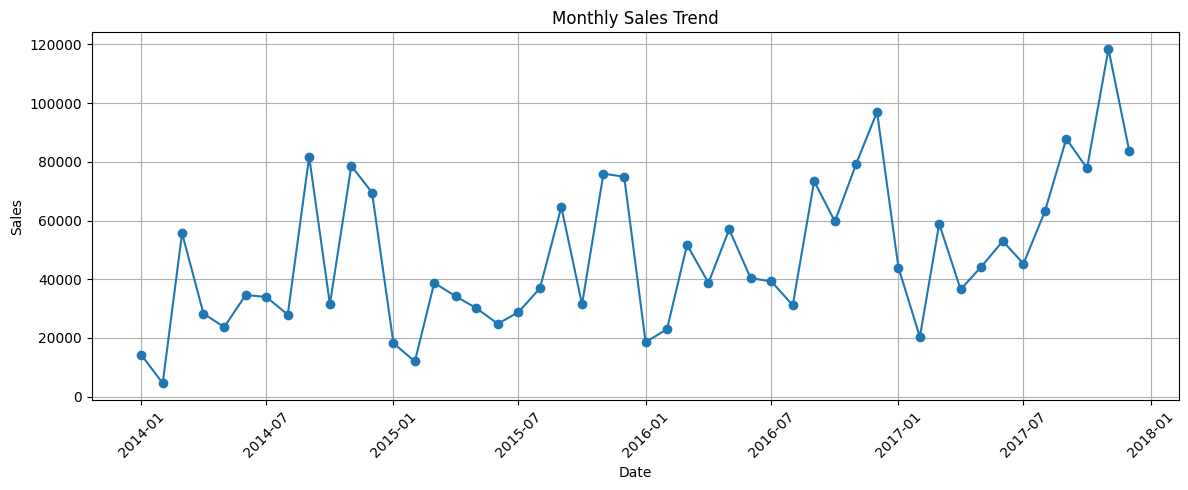

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
forecast_df = monthly_sales[["Date", "Sales"]].copy()

forecast_df["Month"] = forecast_df["Date"].dt.month
forecast_df["Year"] = forecast_df["Date"].dt.year

# Lag features
forecast_df["Lag_1"] = forecast_df["Sales"].shift(1)
forecast_df["Lag_2"] = forecast_df["Sales"].shift(2)
forecast_df["Lag_3"] = forecast_df["Sales"].shift(3)

# Rolling average
forecast_df["Rolling_3"] = forecast_df["Sales"].shift(1).rolling(3).mean()

# Remove missing rows created by lag features
forecast_df = forecast_df.dropna().reset_index(drop=True)

print("Forecasting features created successfully")
print("Rows and Columns:", forecast_df.shape)

forecast_df.head()

Forecasting features created successfully
Rows and Columns: (45, 8)


,Date,Sales,Month,Year,Lag_1,Lag_2,Lag_3,Rolling_3
0,2014-04-01,28295.3450,4,2014,55691.0090,4519.8920,14236.895,24815.932000
1,2014-05-01,23648.2870,5,2014,28295.3450,55691.0090,4519.892,29502.082000
2,2014-06-01,34595.1276,6,2014,23648.2870,28295.3450,55691.009,35878.213667
3,2014-07-01,33946.3930,7,2014,34595.1276,23648.2870,28295.345,28846.253200
4,2014-08-01,27909.4685,8,2014,33946.3930,34595.1276,23648.287,30729.935867


In [17]:
# Prepare features and target

X = forecast_df[
    ["Month", "Year", "Lag_1", "Lag_2", "Lag_3", "Rolling_3"]
]

y = forecast_df["Sales"]

print("Features and target prepared")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target prepared
X shape: (45, 6)
y shape: (45,)


In [18]:
# Chronological train-test split

split_index = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 36
Testing rows: 9


In [19]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully")

XGBoost model trained successfully


In [20]:
y_pred = model.predict(X_test)

print("Predictions generated successfully")
print(y_pred)

Predictions generated successfully
[39649.055 47040.254 38607.117 41659.277 38623.215 78711.7   38009.29
 83263.88  53829.07 ]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 18054.539589583335
Root Mean Squared Error (RMSE): 22706.998206395


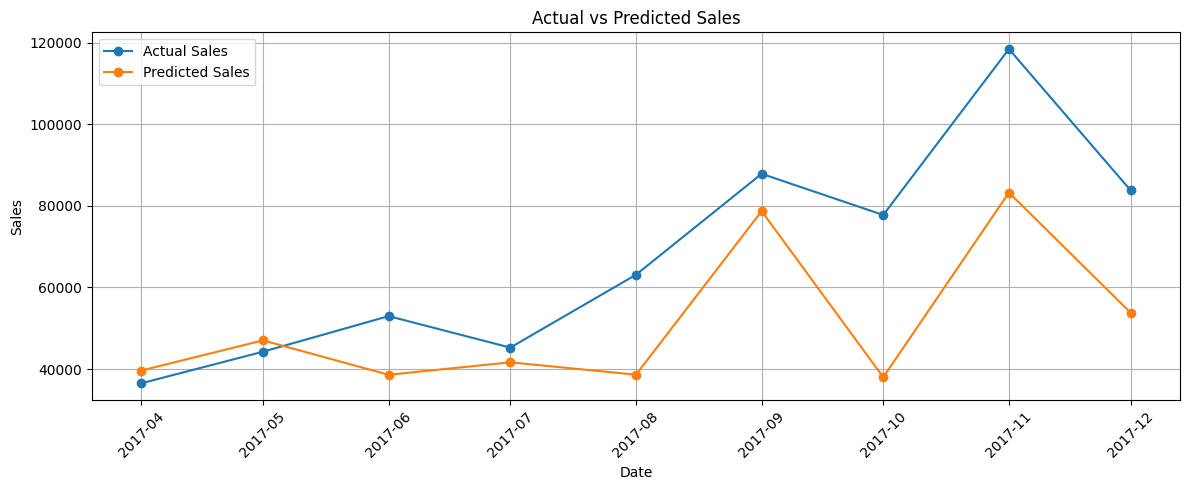

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_df["Date"].iloc[split_index:],
    y_test,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    forecast_df["Date"].iloc[split_index:],
    y_pred,
    label="Predicted Sales",
    marker="o"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
import joblib

joblib.dump(model, "sales_forecast_model.pkl")

print("Model saved successfully")

Model saved successfully


In [24]:
df.to_csv("superstore_cleaned.csv", index=False)

print("Cleaned dataset exported successfully")

Cleaned dataset exported successfully


In [25]:
import streamlit

print("Streamlit is installed successfully")

Streamlit is installed successfully
